# Worked Example

This page walks through a complete `vqlp` workflow on synthetic data:

1. Generate synthetic data (`sklearn.make_blobs`) including **true labels**
2. Fit prototypes via FAISS k-means (`VQFitter`)
3. Run full recall analysis on the learned prototypes (`VQRecaller`), **passing labels to compute WL / WL\_Dist / WL\_Purity**
4. Plot the data and connectivity graph, **colouring prototypes by their winning label (WL)**
5. Inspect all recall products including label summaries


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.datasets import make_blobs

from vqlp import VQFitter

## 1. Generate synthetic data

We create six Gaussian blobs in 2D so the result is easy to plot. We ask for
more prototypes (`M = 20`) than there are blobs, which produces a richer
connectivity (CONN) structure across each blob.

`make_blobs` returns `true_labels` (integer blob IDs 0–5) alongside the data
matrix. We build a fixed per-label colour map here so the same colour is used
consistently across all panels.


In [2]:
N_SAMPLES    = 500
N_BLOBS      = 6
N_FEATURES   = 2      # 2D so we can plot it easily
M_PROTOTYPES = 20     # more prototypes than blobs → richer CONN structure

X, true_labels = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    centers=N_BLOBS,
    cluster_std=0.8,
    random_state=42
)
print(f"Data shape   : {X.shape}")
print(f"Unique labels: {np.unique(true_labels)}")

# Fixed colour map: label i → tab10 colour i (consistent across all panels)
label_cmap   = matplotlib.colormaps.get_cmap("tab10").resampled(N_BLOBS)
label_colors = {lbl: label_cmap(i) for i, lbl in enumerate(np.unique(true_labels))}

Data shape   : (500, 2)
Unique labels: [0 1 2 3 4 5]


## 2. Fit prototypes

With `p=2` (Euclidean), `VQFitter` defaults to the FAISS k-means backend. We
run several restarts (`nredo=3`) and keep the best result. After fitting, the
prototype matrix is available as `fitter.W` with shape `(M, d)`.


In [3]:
fitter = VQFitter(M=M_PROTOTYPES, p=2, max_bmu=2, random_state=42)
fitter.fit(X, method="kmeans", niter=30, nredo=3)

W = fitter.W   # prototype matrix, shape (M, d)
print(f"Prototype matrix shape: {W.shape}")

Running FAISS k-means with 20 clusters (niter=30, nredo=3)...
K-means complete. Final MQE: 0.507609
Fitting complete using kmeans method.
Prototype matrix shape: (20, 2)


WARNING clustering 500 points to 20 centroids: please provide at least 780 training points


## 3. Full recall analysis

`recall()` finalises the recall products (receptive fields, connectivity, etc.)
on the training data. Passing `labels=true_labels` additionally triggers
`recall_labels()`, which computes:

* **`WL`** – winning label per prototype (object array, `None` for empty RFs)
* **`WL_Dist`** – row-normalised fuzzy label frequency table `(M, n_labels)`
* **`WL_Purity`** – Hellinger-based purity score per prototype `(M,)`
* **`WL_unq`** – sorted unique label values (column key for `WL_Dist`)

The underlying `VQRecaller` is exposed as `fitter.recaller`.


In [4]:
fitter.recall(labels=true_labels)   # finalises RF, CONN, AFF, and label recall
recaller = fitter.recaller

Receptive fields computed.
Connectivity matrix computed.
Label recall complete. 20/20 prototypes labeled (6 unique labels). Mean purity: 0.9266
Recall analysis complete. MQE: 0.507609


## 4. Visualize assignments and connectivity

**Left panel** – data points coloured by their *true blob label*; prototype
markers coloured by their *winning label* (WL), so you can immediately see
which blob each prototype represents.

**Right panel** – the CONN graph with the same WL-based node colours; edge
width scales with connectivity strength; node area scales with RF size.


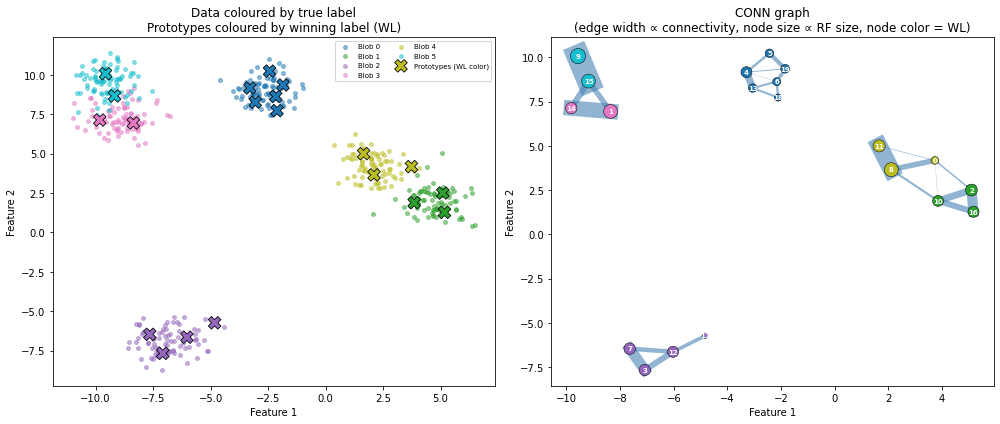

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: data coloured by true label, prototypes by WL ---------------
ax = axes[0]
ax.set_title("Data coloured by true label\nPrototypes coloured by winning label (WL)")

for lbl in np.unique(true_labels):
    mask = true_labels == lbl
    ax.scatter(X[mask, 0], X[mask, 1],
               color=label_colors[lbl], s=15, alpha=0.5, zorder=1,
               label=f"Blob {lbl}")

# Prototype face colour = WL colour; grey if empty RF (WL is None)
proto_colors = [
    label_colors[recaller.WL[i]] if recaller.WL[i] is not None else (0.7, 0.7, 0.7, 1.0)
    for i in range(M_PROTOTYPES)
]
ax.scatter(W[:, 0], W[:, 1],
           c=proto_colors, marker="X", s=160,
           edgecolors="black", linewidths=0.8, zorder=3,
           label="Prototypes (WL color)")

ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

# --- Right panel: CONN graph with WL-coloured nodes --------------------------
ax = axes[1]
ax.set_title("CONN graph\n(edge width ∝ connectivity, node size ∝ RF size, node color = WL)")

conn_csr = recaller.CONN.tocsr()
for i in range(recaller._M):
    for j in recaller.CONN_nhbs[i]:
        if j <= i:   # draw each edge once
            continue
        weight = conn_csr[i, j]
        ax.plot([W[i, 0], W[j, 0]],
                [W[i, 1], W[j, 1]],
                color="steelblue", linewidth=weight * 0.3, alpha=0.6, zorder=1)

rf_sizes = recaller.RFSize
ax.scatter(W[:, 0], W[:, 1],
           s=rf_sizes * 4 + 20,
           c=proto_colors,
           edgecolors="black", linewidths=0.5, zorder=2)

for i, (x, y) in enumerate(W):
    ax.annotate(str(i), (x, y), fontsize=7, ha="center", va="center",
                color="white", fontweight="bold", zorder=3)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


## 5. Inspect the recall products

`get_summary()` returns aggregate statistics; when label recall has been run it
also reports `n_unique_labels`, `labeled_prototypes`, `mean_label_purity`, and
`min_label_purity`.

Below that we inspect the per-observation BMU / QE / **AFF** arrays, the
receptive fields, the connectivity matrix, the **label recall products**, and
finally hard vs. soft reconstruction error.


In [6]:
print("--- get_summary() ---")
summary = fitter.get_summary()
for k, v in summary.items():
    print(f"  {k:35s}: {v}")

--- get_summary() ---
  fitted                             : True
  M                                  : 20
  d                                  : 2
  p_norm                             : 2
  max_bmu                            : 2
  random_state                       : 42
  N                                  : 500
  index_type                         : flat
  mean_quantization_error            : 0.5076089868769049
  empty_prototypes                   : 0
  largest_rf_size                    : 53
  connectivity_edges                 : 26
  mean_connectivity_degree           : 2.6
  max_connectivity_degree            : 4
  n_unique_labels                    : 6
  labeled_prototypes                 : 20
  mean_label_purity                  : 0.9266014122834244
  min_label_purity                   : 0.5567032853699805


In [7]:
print("--- BMU, QE & AFF (first 8 observations) ---")
print(f"  BMU shape : {recaller.BMU.shape} (N x max_bmu)")
print(f"  QE shape  : {recaller.QE.shape} (N x max_bmu)")
print(f"  AFF shape : {recaller.AFF.shape} (N x max_bmu)")
for i in range(8):
    print(f"  obs {i:3d} | 1st BMU: {recaller.BMU[i,0]:3d} QE1: {recaller.QE[i,0]:.4f}"
          f" AFF1: {recaller.AFF[i,0]:.4f}"
          f" | 2nd BMU: {recaller.BMU[i,1]:3d} QE2: {recaller.QE[i,1]:.4f}"
          f" AFF2: {recaller.AFF[i,1]:.4f}")

--- BMU, QE & AFF (first 8 observations) ---
  BMU shape : (500, 2) (N x max_bmu)
  QE shape  : (500, 2) (N x max_bmu)
  AFF shape : (500, 2) (N x max_bmu)
  obs   0 | 1st BMU:  16 QE1: 0.2925 AFF1: 0.8164 | 2nd BMU:  10 QE2: 1.0077 AFF2: 0.1836
  obs   1 | 1st BMU:   9 QE1: 0.2430 AFF1: 0.9436 | 2nd BMU:  15 QE2: 3.8245 AFF2: 0.0564
  obs   2 | 1st BMU:   9 QE1: 1.0912 AFF1: 0.8273 | 2nd BMU:  15 QE2: 4.1360 AFF2: 0.1727
  obs   3 | 1st BMU:  10 QE1: 3.7886 AFF1: 0.7258 | 2nd BMU:   8 QE2: 6.2403 AFF2: 0.2742
  obs   4 | 1st BMU:  14 QE1: 0.2723 AFF1: 0.9390 | 2nd BMU:   1 QE2: 3.9224 AFF2: 0.0610
  obs   5 | 1st BMU:  10 QE1: 0.1096 AFF1: 0.9229 | 2nd BMU:   2 QE2: 1.2015 AFF2: 0.0771
  obs   6 | 1st BMU:   1 QE1: 0.5480 AFF1: 0.8627 | 2nd BMU:  15 QE2: 2.8941 AFF2: 0.1373
  obs   7 | 1st BMU:   9 QE1: 1.7255 AFF1: 0.8404 | 2nd BMU:  15 QE2: 7.3617 AFF2: 0.1596


In [8]:
print("--- Receptive fields (RF) ---")
print(f"  RFSize range: {recaller.RFSize.min()} - {recaller.RFSize.max()} observations")
print(f"  Empty prototypes: {int(np.sum(recaller.RFSize == 0))}")
for i in range(min(5, M_PROTOTYPES)):
    print(f"  RF[{i}]: {recaller.RFSize[i]:3d} obs  ->  indices {recaller.RF[i][:6]}{'...' if recaller.RFSize[i] > 6 else ''}")

--- Receptive fields (RF) ---
  RFSize range: 2 - 53 observations
  Empty prototypes: 0
  RF[0]:  10 obs  ->  indices [41, 115, 150, 168, 190, 196]...
  RF[1]:  43 obs  ->  indices [6, 25, 43, 49, 50, 57]...
  RF[2]:  30 obs  ->  indices [10, 16, 53, 70, 71, 96]...
  RF[3]:  27 obs  ->  indices [18, 19, 97, 114, 128, 134]...
  RF[4]:  25 obs  ->  indices [26, 31, 42, 176, 177, 181]...


In [9]:
print("--- Connectivity matrix (CONN) ---")
print(f"  CONN shape  : {recaller.CONN.shape}   (M x M, sparse)")
print(f"  Nonzero entries: {recaller.CONN.nnz}  ({summary['connectivity_edges']} unique edges)")
print(f"  Degree range: {recaller.CONN_nhbs_size.min()} - {recaller.CONN_nhbs_size.max()} neighbours")
print(f"  Mean degree : {summary['mean_connectivity_degree']:.2f}")
for i in range(min(5, M_PROTOTYPES)):
    print(f"  Prototype {i:2d}: {recaller.CONN_nhbs_size[i]} neighbours  ->  {recaller.CONN_nhbs[i]}")

--- Connectivity matrix (CONN) ---
  CONN shape  : (20, 20)   (M x M, sparse)
  Nonzero entries: 52  (26 unique edges)
  Degree range: 1 - 4 neighbours
  Mean degree : 2.60
  Prototype  0: 4 neighbours  ->  [2, 8, 10, 11]
  Prototype  1: 2 neighbours  ->  [14, 15]
  Prototype  2: 3 neighbours  ->  [0, 10, 16]
  Prototype  3: 2 neighbours  ->  [7, 12]
  Prototype  4: 4 neighbours  ->  [5, 6, 13, 19]


In [10]:
print("--- Label recall (WL / WL_Dist / WL_Purity) ---")
print(f"  Unique labels seen : {recaller.WL_unq}")
print(f"  WL shape           : {recaller.WL.shape}  (winning label per prototype)")
print(f"  WL_Dist shape      : {recaller.WL_Dist.shape}  (M x n_unique_labels, row-normalised)")
print(f"  WL_Purity shape    : {recaller.WL_Purity.shape}")
print()
print(f"  {'Proto':>6}  {'WL':>5}  {'Purity':>7}  {'RF size':>7}  WL_Dist (per label)")
print(f"  {'-----':>6}  {'--':>5}  {'------':>7}  {'-------':>7}  "
      + "  ".join(f"L{l}" for l in recaller.WL_unq))
for i in range(M_PROTOTYPES):
    wl_str   = str(recaller.WL[i]) if recaller.WL[i] is not None else 'None'
    dist_str = "  ".join(f"{recaller.WL_Dist[i, j]:.3f}" for j in range(len(recaller.WL_unq)))
    print(f"  {i:6d}  {wl_str:>5}  {recaller.WL_Purity[i]:7.4f}  {recaller.RFSize[i]:7d}  {dist_str}")


--- Label recall (WL / WL_Dist / WL_Purity) ---
  Unique labels seen : [0 1 2 3 4 5]
  WL shape           : (20,)  (winning label per prototype)
  WL_Dist shape      : (20, 6)  (M x n_unique_labels, row-normalised)
  WL_Purity shape    : (20,)

   Proto     WL   Purity  RF size  WL_Dist (per label)
   -----     --   ------  -------  L0  L1  L2  L3  L4  L5
       0      4   0.6281       10  0.000  0.257  0.000  0.000  0.743  0.000
       1      3   0.9046       43  0.000  0.000  0.000  0.982  0.000  0.018
       2      1   0.9769       30  0.000  0.999  0.000  0.000  0.001  0.000
       3      2   1.0000       27  0.000  0.000  1.000  0.000  0.000  0.000
       4      0   1.0000       25  1.000  0.000  0.000  0.000  0.000  0.000
       5      0   1.0000       13  1.000  0.000  0.000  0.000  0.000  0.000
       6      0   1.0000       11  1.000  0.000  0.000  0.000  0.000  0.000
       7      2   1.0000       28  0.000  0.000  1.000  0.000  0.000  0.000
       8      4   0.9279       44 

In [11]:
print("--- Reconstruction ---")
X_hard = recaller.reconstruct(W, X, method="hard")
X_soft = recaller.reconstruct(W, X, method="soft")
hard_err = np.mean(np.linalg.norm(X - X_hard, axis=1))
soft_err = np.mean(np.linalg.norm(X - X_soft, axis=1))
print(f"  Hard reconstruction mean L2 error: {hard_err:.4f}")
print(f"  Soft reconstruction mean L2 error: {soft_err:.4f}")

--- Reconstruction ---
Soft reconstruction complete.
  Hard reconstruction mean L2 error: 0.6287
  Soft reconstruction mean L2 error: 0.6148
